# The Evolution of Self-Distillation: A Gentle Introduction

This notebook presents a comprehensive timeline and explanation of knowledge self-distillation research, tracing the progression from foundational concepts to modern applications in continual learning and language models.

## What is Self-Distillation?

**For someone with grad school math + basic MLP/RL knowledge:**

Imagine you have a neural network (an MLP or CNN) trained on some task. Traditional **knowledge distillation** (Hinton et al., 2015) works like this:
- Train a large, accurate "teacher" model
- Train a smaller "student" model to mimic the teacher's outputs
- The student learns from the teacher's "soft" probability distributions (not just hard labels)

**Self-distillation** asks: *What if the teacher and student are the same network?*

The core insight: A model can improve itself by learning from its own predictions, creating a virtuous cycle of self-improvement without needing external teachers.

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import pandas as pd
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

## Timeline of Self-Distillation Research

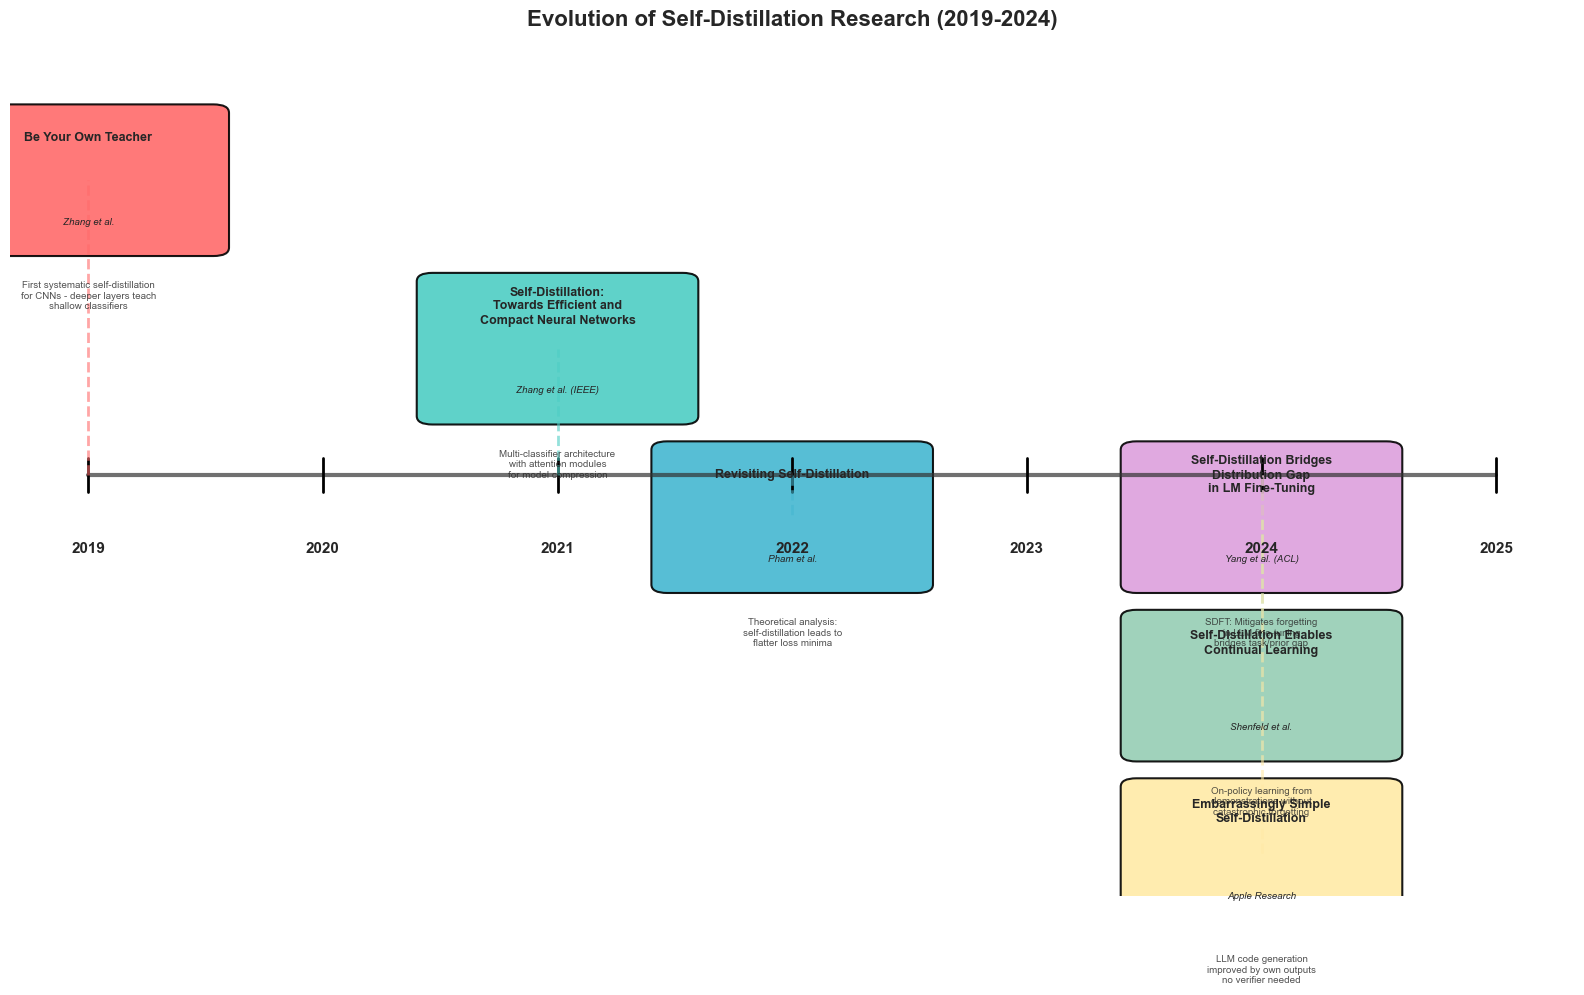

Timeline saved as 'timeline.png'


In [12]:
# Create timeline visualization
fig, ax = plt.subplots(figsize=(16, 10))

# Paper data: (year, title, authors, key_contribution, y_position, color)
papers = [
    (2019, "Be Your Own Teacher", "Zhang et al.", "First systematic self-distillation\nfor CNNs - deeper layers teach\nshallow classifiers", 0.85, '#FF6B6B'),
    (2021, "Self-Distillation:\nTowards Efficient and\nCompact Neural Networks", "Zhang et al. (IEEE)", "Multi-classifier architecture\nwith attention modules\nfor model compression", 0.65, '#4ECDC4'),
    (2022, "Revisiting Self-Distillation", "Pham et al.", "Theoretical analysis:\nself-distillation leads to\nflatter loss minima", 0.45, '#45B7D1'),
    (2024, "Self-Distillation Enables\nContinual Learning", "Shenfeld et al.", "On-policy learning from\ndemonstrations without\ncatastrophic forgetting", 0.25, '#96CEB4'),
    (2024, "Embarrassingly Simple\nSelf-Distillation", "Apple Research", "LLM code generation\nimproved by own outputs\nno verifier needed", 0.05, '#FFEAA7'),
    (2024, "Self-Distillation Bridges\nDistribution Gap\nin LM Fine-Tuning", "Yang et al. (ACL)", "SDFT: Mitigates forgetting\nin LLM fine-tuning\nbridges task/prior gap", 0.45, '#DDA0DD')
]

# Draw timeline axis
ax.axhline(y=0.5, xmin=0.05, xmax=0.95, color='#333333', linewidth=3, alpha=0.7)

# Add year markers
for year in [2019, 2020, 2021, 2022, 2023, 2024, 2025]:
    x_pos = 0.05 + (year - 2019) / 6 * 0.9
    ax.plot([x_pos, x_pos], [0.48, 0.52], 'k-', linewidth=2)
    ax.text(x_pos, 0.42, str(year), ha='center', va='top', fontsize=11, fontweight='bold')

# Draw paper boxes
for year, title, authors, contribution, y_pos, color in papers:
    x_pos = 0.05 + (year - 2019) / 6 * 0.9
    
    # Draw connection line
    ax.plot([x_pos, x_pos], [0.5, y_pos], color=color, linewidth=2, alpha=0.6, linestyle='--')
    
    # Draw paper box
    box = FancyBboxPatch((x_pos - 0.08, y_pos - 0.08), 0.16, 0.16,
                         boxstyle="round,pad=0.01",
                         facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.9)
    ax.add_patch(box)
    
    # Add text
    ax.text(x_pos, y_pos + 0.05, title, ha='center', va='center', fontsize=9, fontweight='bold', wrap=True)
    ax.text(x_pos, y_pos - 0.05, authors, ha='center', va='center', fontsize=7, style='italic')
    
    # Add contribution text below
    ax.text(x_pos, y_pos - 0.12, contribution, ha='center', va='top', fontsize=7, alpha=0.8)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Evolution of Self-Distillation Research (2019-2024)', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('timeline.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Timeline saved as 'timeline.png'")

## Summary Statistics Table

In [13]:
# Create summary table
summary_data = {
    'Paper': [
        'Be Your Own Teacher (2019)',
        'Self-Distillation: Efficient & Compact (2021)',
        'Revisiting Self-Distillation (2022)',
        'Self-Distillation Enables Continual Learning (2024)',
        'Embarrassingly Simple Self-Distillation (2024)',
        'Self-Distillation Bridges Distribution Gap (2024)'
    ],
    'Venue': ['ICCV', 'IEEE TPAMI', 'arXiv', 'arXiv', 'arXiv', 'ACL'],
    'Domain': ['Computer Vision', 'Computer Vision', 'General ML', 'Continual Learning', 'Code Generation', 'NLP/LLMs'],
    'Key Innovation': [
        'Deep-to-shallow knowledge transfer',
        'Multi-classifier with attention',
        'Loss landscape flatness theory',
        'On-policy learning from demonstrations',
        'Temperature-based self-improvement',
        'Distribution gap bridging in fine-tuning'
    ],
    'Teacher-Student Relation': [
        'Same network, different depths',
        'Same network + attention modules',
        'Same architecture, same weights',
        'Demonstration-conditioned vs base',
        'Same model, different temperatures',
        'Fine-tuned vs pre-trained'
    ],
    'Main Benefit': [
        'Accuracy boost + depth scalability',
        'Model compression',
        'Better generalization',
        'No catastrophic forgetting',
        'No external teacher/verifier needed',
        'Preserves prior capabilities'
    ]
}

df = pd.DataFrame(summary_data)
display(df.style.set_properties(**{'text-align': 'left'})
          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left'), ('font-weight', 'bold')]}])
          .set_caption('Summary of Self-Distillation Papers'))

,Paper,Venue,Domain,Key Innovation,Teacher-Student Relation,Main Benefit
0,Be Your Own Teacher (2019),ICCV,Computer Vision,Deep-to-shallow knowledge transfer,"Same network, different depths",Accuracy boost + depth scalability
1,Self-Distillation: Efficient & Compact (2021),IEEE TPAMI,Computer Vision,Multi-classifier with attention,Same network + attention modules,Model compression
2,Revisiting Self-Distillation (2022),arXiv,General ML,Loss landscape flatness theory,"Same architecture, same weights",Better generalization
3,Self-Distillation Enables Continual Learning (2024),arXiv,Continual Learning,On-policy learning from demonstrations,Demonstration-conditioned vs base,No catastrophic forgetting
4,Embarrassingly Simple Self-Distillation (2024),arXiv,Code Generation,Temperature-based self-improvement,"Same model, different temperatures",No external teacher/verifier needed
5,Self-Distillation Bridges Distribution Gap (2024),ACL,NLP/LLMs,Distribution gap bridging in fine-tuning,Fine-tuned vs pre-trained,Preserves prior capabilities


## The Mathematics of Self-Distillation

### Traditional Knowledge Distillation

Given a teacher model $T$ and student model $S$, the distillation loss is:

$$\mathcal{L}_{KD} = \alpha \cdot \text{CE}(y, S(x)) + (1-\alpha) \cdot \tau^2 \text{KL}\left(\text{softmax}\left(\frac{T(x)}{\tau}\right), \text{softmax}\left(\frac{S(x)}{\tau}\right)\right)$$

Where:
- $\tau$ = temperature parameter (softens probability distributions)
- $\alpha$ = weight balancing hard and soft targets
- CE = cross-entropy loss
- KL = Kullback-Leibler divergence

### Self-Distillation: The Key Difference

In self-distillation, $T = S$ (same network) or $T$ is a previous checkpoint of the same network:

$$\mathcal{L}_{SD} = \alpha \cdot \text{CE}(y, f_\theta(x)) + (1-\alpha) \cdot \text{KL}(f_{\theta'}(x), f_\theta(x))$$

Where $\theta'$ represents either:
1. **Deep layers teaching shallow layers** (Zhang et al., 2019)
2. **Previous checkpoint** (continual learning)
3. **Higher temperature version** (Embarrassingly Simple SD)
4. **Demonstration-conditioned model** (SDFT)

## Evolution of Concepts: Interactive Animation

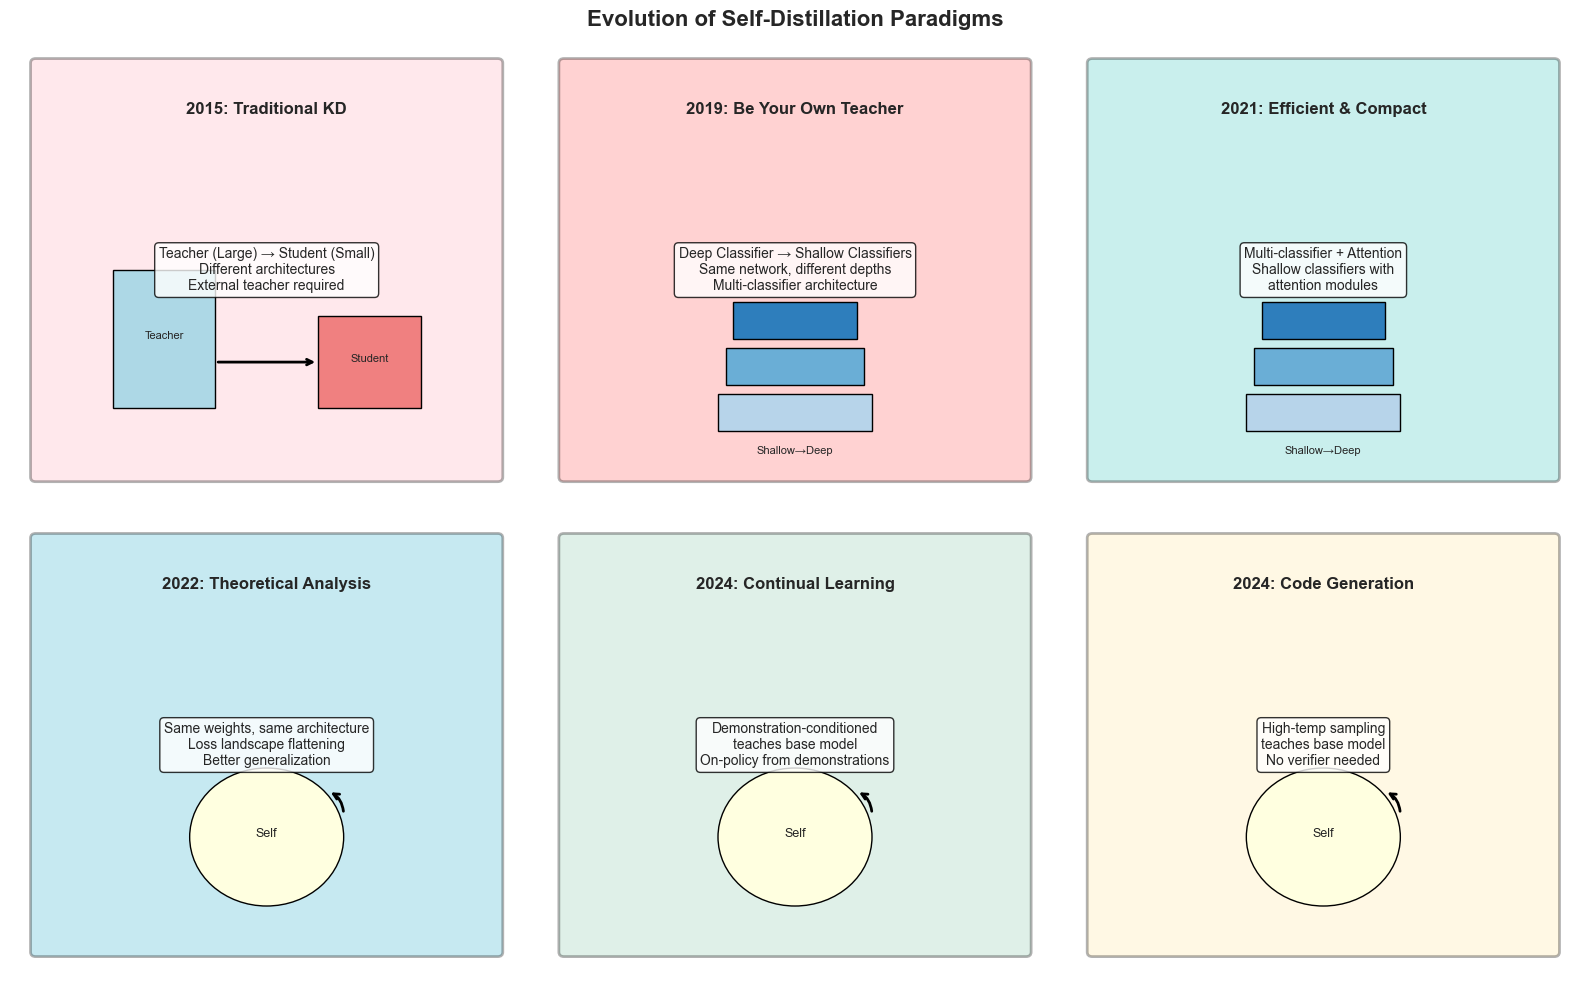

Evolution stages saved as 'evolution_stages.png'


In [14]:
# Create animated visualization of self-distillation evolution
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

stages = [
    ("2015: Traditional KD", "Teacher (Large) → Student (Small)\nDifferent architectures\nExternal teacher required", '#FFB6C1'),
    ("2019: Be Your Own Teacher", "Deep Classifier → Shallow Classifiers\nSame network, different depths\nMulti-classifier architecture", '#FF6B6B'),
    ("2021: Efficient & Compact", "Multi-classifier + Attention\nShallow classifiers with\nattention modules", '#4ECDC4'),
    ("2022: Theoretical Analysis", "Same weights, same architecture\nLoss landscape flattening\nBetter generalization", '#45B7D1'),
    ("2024: Continual Learning", "Demonstration-conditioned\nteaches base model\nOn-policy from demonstrations", '#96CEB4'),
    ("2024: Code Generation", "High-temp sampling\nteaches base model\nNo verifier needed", '#FFEAA7')
]

for idx, (title, desc, color) in enumerate(stages):
    ax = axes[idx]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Draw background
    rect = FancyBboxPatch((0.5, 0.5), 9, 9, boxstyle="round,pad=0.1",
                         facecolor=color, edgecolor='black', linewidth=2, alpha=0.3)
    ax.add_patch(rect)
    
    # Add title
    ax.text(5, 8.5, title, ha='center', va='center', fontsize=12, fontweight='bold')
    
    # Add description
    ax.text(5, 5, desc, ha='center', va='center', fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Draw simple network diagram based on stage
    if idx == 0:
        # Traditional KD: Two separate networks
        ax.add_patch(plt.Rectangle((2, 2), 2, 3, facecolor='lightblue', edgecolor='black'))
        ax.text(3, 3.5, 'Teacher', ha='center', fontsize=8)
        ax.add_patch(plt.Rectangle((6, 2), 2, 2, facecolor='lightcoral', edgecolor='black'))
        ax.text(7, 3, 'Student', ha='center', fontsize=8)
        ax.annotate('', xy=(6, 3), xytext=(4, 3), arrowprops=dict(arrowstyle='->', lw=2))
    elif idx in [1, 2]:
        # Multi-classifier
        for i, y in enumerate([1.5, 2.5, 3.5]):
            width = 3 - i * 0.3
            ax.add_patch(plt.Rectangle((5-width/2, y), width, 0.8, 
                                      facecolor=plt.cm.Blues(0.3 + i*0.2), edgecolor='black'))
        ax.text(5, 1, 'Shallow→Deep', ha='center', fontsize=8)
    else:
        # Self-loop
        ax.add_patch(plt.Circle((5, 3), 1.5, facecolor='lightyellow', edgecolor='black'))
        ax.text(5, 3, 'Self', ha='center', fontsize=9)
        ax.annotate('', xy=(6.2, 4), xytext=(6.5, 3.5), 
                   arrowprops=dict(arrowstyle='->', lw=2, connectionstyle='arc3,rad=0.3'))

plt.suptitle('Evolution of Self-Distillation Paradigms', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('evolution_stages.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Evolution stages saved as 'evolution_stages.png'")

## Key Insights Across the Timeline

### 1. **2019: Be Your Own Teacher** (Zhang et al., ICCV)

**The Breakthrough:** First systematic approach where deeper layers of a CNN teach shallower auxiliary classifiers.

**Key Idea:** Attach shallow classifiers at intermediate layers. The deepest (most accurate) classifier supervises the shallow ones through:
- **Label loss:** Standard cross-entropy with ground truth
- **Distillation loss:** KL divergence from deep classifier's soft predictions
- **Hint loss:** L2 distance between intermediate feature maps

**Result:** Same network achieves better accuracy + enables depth-wise scalable inference (deploy smaller classifiers on edge devices).

---

### 2. **2021: Towards Efficient and Compact Neural Networks** (Zhang et al., IEEE TPAMI)

**Extension:** Adds attention modules to the multi-classifier architecture.

**Key Components:**
- **Attention modules:** Help shallow classifiers focus on relevant features
- **Response distillation:** Transforms deep classifier responses for better shallow learning
- **Feature-adaptive distillation:** Adjusts feature map sizes for comparison

**Result:** Better model compression while maintaining accuracy.

---

### 3. **2022: Revisiting Self-Distillation** (Pham et al.)

**Theoretical Contribution:** Explains WHY self-distillation works.

**Key Finding:** Self-distillation leads to **flatter loss minima**, which correlates with better generalization.

**Mechanism:**
1. Start with trained teacher (at some local minimum)
2. Train student with soft targets from teacher
3. Student finds wider, flatter minimum nearby
4. Better generalization on held-out data

**Surprising Result:** Student can outperform teacher despite identical architecture!

---

### 4. **2024: Self-Distillation Enables Continual Learning** (Shenfeld et al.)

**New Application:** Using self-distillation for continual learning without catastrophic forgetting.

**Problem:** Standard supervised fine-tuning (SFT) forgets previous tasks when learning new ones.

**Solution - SDFT (Self-Distillation Fine-Tuning):**
- Use demonstration-conditioned model as teacher
- Base model learns from these on-policy signals
- Preserves prior knowledge while acquiring new skills

**Key Insight:** Enables accumulation of multiple skills over time without performance regression.

---

### 5. **2024: Embarrassingly Simple Self-Distillation** (Apple Research)

**Focus:** Code generation with LLMs.

**Method:**
1. Sample multiple solutions from model at high temperature
2. Filter correct solutions (using test cases)
3. Fine-tune model on its own correct outputs

**Key Advantage:** No external teacher, no verifier, no reinforcement learning needed!

**Why it works:** High-temperature sampling produces diverse solutions; correct ones serve as quality training data.

---

### 6. **2024: Self-Distillation Bridges Distribution Gap in Language Model Fine-Tuning** (Yang et al., ACL)

**Problem:** Fine-tuning LLMs causes catastrophic forgetting and breaks alignment.

**Root Cause:** Distribution gap between task data and pre-training distribution.

**Solution - SDFT:**
- Teacher: Demonstration-conditioned model (knows the task)
- Student: Base model (preserves general capabilities)
- Training signal bridges the gap between these distributions

**Result:** Mitigates forgetting while achieving comparable downstream performance.

## Animation: The Self-Distillation Process

In [15]:
# Create a simple animation showing the self-distillation process
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Static elements
title = ax.text(5, 9.5, 'Self-Distillation Process', ha='center', fontsize=14, fontweight='bold')

# Draw model box
model_box = plt.Rectangle((3.5, 4), 3, 3, facecolor='lightblue', edgecolor='black', linewidth=2)
ax.add_patch(model_box)
model_text = ax.text(5, 5.5, 'Neural Network\n(Student)', ha='center', va='center', fontsize=10)

# Draw teacher (initially hidden or same)
teacher_box = plt.Rectangle((0.5, 4), 2.5, 3, facecolor='lightyellow', edgecolor='black', linewidth=2, alpha=0.3)
ax.add_patch(teacher_box)
teacher_text = ax.text(1.75, 5.5, 'Teacher\n(Deep Layer)', ha='center', va='center', fontsize=9, alpha=0.3)

# Data input
data_circle = plt.Circle((5, 1.5), 0.8, facecolor='lightgreen', edgecolor='black')
ax.add_patch(data_circle)
data_text = ax.text(5, 1.5, 'Input', ha='center', va='center', fontsize=9)

# Arrows (initially invisible)
arrow1 = FancyArrowPatch((5, 2.3), (5, 4), arrowstyle='->', mutation_scale=20, 
                        linewidth=2, color='green', alpha=0)
ax.add_patch(arrow1)

arrow2 = FancyArrowPatch((3.5, 5.5), (3, 5.5), arrowstyle='->', mutation_scale=20,
                        linewidth=2, color='blue', alpha=0)
ax.add_patch(arrow2)

# Loss and update indicators
loss_text = ax.text(5, 3, '', ha='center', fontsize=10, color='red')
update_text = ax.text(5, 2, '', ha='center', fontsize=10, color='purple')

def animate(frame):
    if frame < 20:
        # Phase 1: Input flows to model
        arrow1.set_alpha(frame / 20)
        loss_text.set_text('Forward Pass')
    elif frame < 40:
        # Phase 2: Knowledge transfer from teacher
        teacher_box.set_alpha(0.3 + (frame - 20) / 20 * 0.7)
        teacher_text.set_alpha(0.3 + (frame - 20) / 20 * 0.7)
        arrow2.set_alpha((frame - 20) / 20)
        loss_text.set_text('Computing Distillation Loss')
    elif frame < 60:
        # Phase 3: Update
        update_text.set_text('Update: θ ← θ - α∇L')
        model_box.set_facecolor(plt.cm.Blues(0.3 + (frame - 40) / 20 * 0.4))
    else:
        # Phase 4: Converged
        loss_text.set_text('Self-Improved Model')
        update_text.set_text('')
        
    return [arrow1, arrow2, teacher_box, loss_text, update_text, model_box]

anim = FuncAnimation(fig, animate, frames=80, interval=100, blit=False)
plt.tight_layout()

# Use to_jshtml() instead of to_html5_video() (doesn't require ffmpeg)
html_video = anim.to_jshtml()
plt.close()
HTML(html_video)

C:\Users\Aymen\AppData\Local\Temp\ipykernel_10396\484113771.py:64: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  html_video = anim.to_jshtml()


## Conclusion

The evolution of self-distillation demonstrates a fascinating progression:

1. **2015-2019:** From external teachers to self-improvement (Be Your Own Teacher)
2. **2020-2022:** Architectural innovations and theoretical understanding (Multi-classifier, Loss landscape)
3. **2023-2024:** Applications to continual learning and LLMs (SDFT, Code generation)

**The Core Principle:** A model can bootstrap its own improvement by learning from its own (or its variants') predictions. This eliminates the need for:
- Large pre-trained teachers
- External verifiers
- Complex reinforcement learning setups

**Future Directions:**
- Scaling to larger foundation models
- Combining with other training paradigms
- Theoretical understanding of convergence properties
- Applications in multi-modal and embodied AI